# 03 — Implied Volatility

**Phase 3 deliverable** 

Phase 1 built Black-Scholes-Merton as $\sigma \rightarrow \text{Price}$. This notebook reverses
it: $\text{Market Price} \rightarrow \sigma_{\text{implied}}$, using a numerical root-finder,
for every cleaned contract from Phase 2 across all seven assets (USO, JETS, SPY, XLE, XLY, XLV,
GLD).

Steps:

1. Reload the Phase 2 cleaned tables.
2. Build a robust implied-volatility solver (bisection via `scipy.optimize.brentq`).
3. Solve for every contract; flag rows with no valid solution instead of crashing.
4. Feed implied volatility back into Black-Scholes to get market-implied Greeks.
5. Plot volatility smiles across strikes for each asset.
6. Save one enriched table per underlying.


## 1. Setup and reload Phase 2 output

If `data/cleaned/*.csv` isn't present (e.g. this notebook is run standalone), re-run
`02_market_data_cleaning.ipynb` first — Phase 3 builds directly on its output.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import os

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

TICKERS = ["USO", "JETS", "SPY", "XLE", "XLY", "XLV", "GLD"]

os.makedirs("data/iv", exist_ok=True)

clean_chains = {}
for ticker in TICKERS:
    path = f"data/cleaned/{ticker}_clean.csv"
    df = pd.read_csv(path, parse_dates=["expiration"])
    clean_chains[ticker] = df
    print(f"{ticker}: loaded {len(df)} cleaned contracts")


USO: loaded 62 cleaned contracts
JETS: loaded 65 cleaned contracts
SPY: loaded 53 cleaned contracts
XLE: loaded 66 cleaned contracts
XLY: loaded 49 cleaned contracts
XLV: loaded 49 cleaned contracts
GLD: loaded 49 cleaned contracts


## 2. Black-Scholes pricing (from Phase 1)

Restated here so this notebook is self-contained.


## 2. Black-Scholes pricing and Greeks (from `src/`)

Rather than redefining the Phase 1 engine again here, this notebook imports the same, tested
implementation used everywhere else in the project (see `src/geopolitical_options/`, and its
test suite in `tests/`). This keeps a single source of truth for the math.


In [2]:
import sys
sys.path.insert(0, "../src")

from geopolitical_options.black_scholes import d1_d2, bs_price
from geopolitical_options.greeks import bs_greeks
from geopolitical_options.implied_volatility import implied_volatility as _iv_solver

print("Imported black_scholes, greeks, and implied_volatility from geopolitical_options")


Imported black_scholes, greeks, and implied_volatility from geopolitical_options


## 3. The implied-volatility solver

We want $\sigma$ such that $BS(\sigma) - \text{Market Price} = 0$.

**Plain-English version:** try a volatility, see if the model price came out too high or too
low, adjust, repeat — the classic "try 20%, too low; try 40%, too high; try 31%, close enough"
process described in the plan. `brentq` automates that bisection-style search far more
efficiently than manual guessing, but it needs a bracket: a low and high volatility where the
pricing error has opposite signs. We use a wide bracket (0.5% to 500% annualized vol) since
options can occasionally require extreme implied vols to match a stale or illiquid quote.

The solver must not crash on bad data — it should flag those rows instead. The imported
`implied_volatility` function returns a small named tuple, `(iv, success, message)`, which this
notebook unpacks the same way a 3-item tuple would be.


In [3]:
def implied_volatility(market_price, S, K, T, r, q, right, low=0.005, high=5.0):
    """Thin wrapper so the rest of this notebook can call implied_volatility(...) exactly as
    before -- the real implementation lives in src/geopolitical_options/implied_volatility.py
    and is unit-tested in tests/test_implied_volatility.py."""
    result = _iv_solver(market_price, S, K, T, r, q, right, low=low, high=high)
    return result.iv, result.success, result.message


## 4. Solve implied volatility for every contract

Applied row-by-row across all seven cleaned tables. Failures are kept in the table (with `iv`
as `NaN`) rather than silently dropped, so we can see how often -- and where -- the solver
struggles.


In [4]:
def solve_chain_iv(df):
    ivs, successes, messages = [], [], []
    for row in df.itertuples(index=False):
        iv, ok, msg = implied_volatility(
            market_price=row.midpoint, S=row.underlying_price, K=row.strike,
            T=row.T, r=row.risk_free_rate, q=row.dividend_yield, right=row.right,
        )
        ivs.append(iv)
        successes.append(ok)
        messages.append(msg)

    out = df.copy()
    out["implied_vol"] = ivs
    out["iv_solved"] = successes
    out["iv_message"] = messages
    return out


iv_chains = {}
for ticker in TICKERS:
    iv_chains[ticker] = solve_chain_iv(clean_chains[ticker])
    n_ok = iv_chains[ticker]["iv_solved"].sum()
    n_total = len(iv_chains[ticker])
    print(f"{ticker}: {n_ok}/{n_total} contracts solved "
          f"({n_ok / n_total:.0%})")


USO: 62/62 contracts solved (100%)
JETS: 65/65 contracts solved (100%)


SPY: 53/53 contracts solved (100%)


XLE: 66/66 contracts solved (100%)
XLY: 49/49 contracts solved (100%)


XLV: 49/49 contracts solved (100%)


GLD: 49/49 contracts solved (100%)


## 5. Look at solver failures

Understanding *why* a contract failed matters as much as knowing that it did -- it tells you
whether the upstream Phase 2 filters need to be tighter.


In [5]:
failure_summary = (
    pd.concat(iv_chains.values())
    .loc[lambda d: ~d["iv_solved"], "iv_message"]
    .value_counts()
)
if failure_summary.empty:
    print("No implied-volatility solver failures across any ticker.")
else:
    print("Failure reasons across all tickers:")
    print(failure_summary)


No implied-volatility solver failures across any ticker.


## 6. Market-implied Greeks

Feed the solved implied volatility back into the Phase 1 Greeks formulas -- this gives Delta,
Gamma, Vega, Theta, and Rho as the *market* currently prices them, not as a single assumed
volatility would imply.


In [6]:
def attach_greeks(df):
    out = df.copy()
    deltas, gammas, vegas, thetas, rhos = [], [], [], [], []
    for row in out.itertuples(index=False):
        if not row.iv_solved:
            deltas.append(np.nan); gammas.append(np.nan); vegas.append(np.nan)
            thetas.append(np.nan); rhos.append(np.nan)
            continue
        g = bs_greeks(row.underlying_price, row.strike, row.T,
                      row.risk_free_rate, row.implied_vol, row.dividend_yield, row.right)
        deltas.append(g["delta"]); gammas.append(g["gamma"]); vegas.append(g["vega"])
        thetas.append(g["theta"]); rhos.append(g["rho"])

    out["delta"] = deltas
    out["gamma"] = gammas
    out["vega"] = vegas
    out["theta"] = thetas
    out["rho"] = rhos
    return out


for ticker in TICKERS:
    iv_chains[ticker] = attach_greeks(iv_chains[ticker])

iv_chains["SPY"][[
    "right", "strike", "expiration", "T", "moneyness",
    "midpoint", "implied_vol", "delta", "gamma", "vega", "theta"
]].dropna().head(10)


,right,strike,expiration,T,moneyness,midpoint,implied_vol,delta,gamma,vega,theta
0,call,601.5,2026-08-18,0.082192,0.800048,151.810,0.204735,0.998961,0.000005,0.000469,-0.049347
1,call,639.1,2026-08-18,0.082192,0.850059,114.370,0.198999,0.997285,0.000129,0.011970,-0.057659
2,call,714.2,2026-08-18,0.082192,0.949949,42.675,0.185732,0.850424,0.005786,0.499235,-0.207085
3,call,751.8,2026-08-18,0.082192,0.999960,16.340,0.178202,0.531125,0.010343,0.856340,-0.288424
4,call,789.4,2026-08-18,0.082192,1.049971,3.500,0.170676,0.179483,0.007117,0.564356,-0.172305
5,call,827.0,2026-08-18,0.082192,1.099983,0.330,0.163146,0.025206,0.001673,0.126823,-0.036157
6,call,601.5,2026-09-02,0.123288,0.800048,152.555,0.201838,0.997926,0.000039,0.005514,-0.050261
7,call,639.1,2026-09-02,0.123288,0.850059,115.280,0.196721,0.991295,0.000386,0.052899,-0.064732
8,call,676.6,2026-09-02,0.123288,0.899937,78.840,0.189203,0.952253,0.001940,0.255806,-0.108785
9,call,751.8,2026-09-02,0.123288,0.999960,19.855,0.174167,0.538141,0.008623,1.046579,-0.236664


## 7. Save one enriched table per underlying

In [7]:
for ticker in TICKERS:
    iv_chains[ticker].to_csv(f"data/iv/{ticker}_iv.csv", index=False)
    print(f"Saved data/iv/{ticker}_iv.csv "
          f"({iv_chains[ticker]['iv_solved'].sum()} solved rows)")


Saved data/iv/USO_iv.csv (62 solved rows)
Saved data/iv/JETS_iv.csv (65 solved rows)
Saved data/iv/SPY_iv.csv (53 solved rows)
Saved data/iv/XLE_iv.csv (66 solved rows)
Saved data/iv/XLY_iv.csv (49 solved rows)
Saved data/iv/XLV_iv.csv (49 solved rows)
Saved data/iv/GLD_iv.csv (49 solved rows)


## 8. Volatility smiles

For each asset, at the shortest available expiration, plot implied volatility against
moneyness ($K/S$) for calls and puts. Lower-strike puts richer than at-the-money is the classic
downside-protection skew mentioned in the plan.


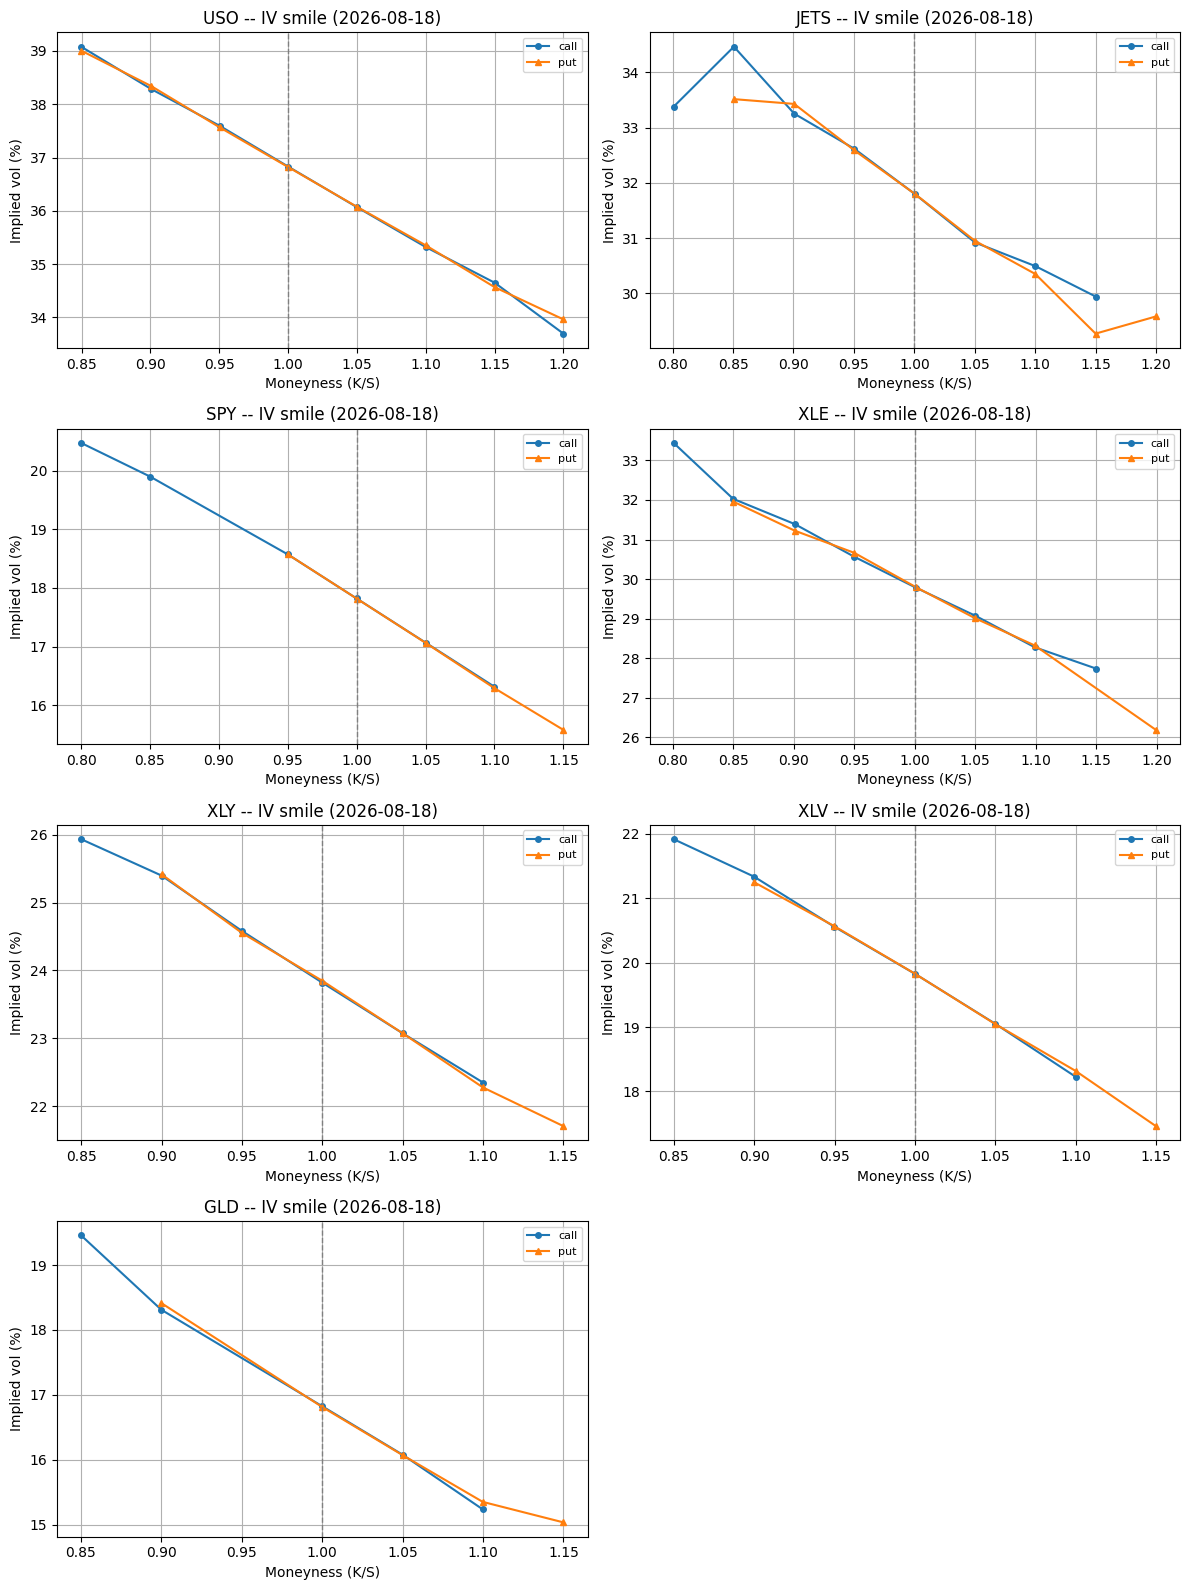

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    d = iv_chains[ticker].dropna(subset=["implied_vol"])
    if d.empty:
        axes[i].set_title(f"{ticker}: no solved contracts")
        continue

    nearest_exp = d["expiration"].min()
    d_near = d[d["expiration"] == nearest_exp]

    for right, marker in [("call", "o"), ("put", "^")]:
        sub = d_near[d_near["right"] == right].sort_values("moneyness")
        axes[i].plot(sub["moneyness"], sub["implied_vol"] * 100,
                     marker=marker, label=right, linewidth=1.5, markersize=4)

    axes[i].axvline(1.0, color="gray", linestyle="--", linewidth=1)
    axes[i].set_title(f"{ticker} -- IV smile ({nearest_exp.date()})")
    axes[i].set_xlabel("Moneyness (K/S)")
    axes[i].set_ylabel("Implied vol (%)")
    axes[i].legend(fontsize=8)

# Hide the unused 8th subplot (7 tickers, 8 grid slots)
if len(TICKERS) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.savefig("iv_smiles.png", dpi=130)
plt.show()


## 9. At-the-money implied volatility across assets

A quick first look at Hypothesis 1 from the project's research question: does oil-linked
implied volatility sit meaningfully above the broad market's?


In [9]:
atm_rows = []
for ticker in TICKERS:
    d = iv_chains[ticker].dropna(subset=["implied_vol"])
    if d.empty:
        continue
    nearest_exp = d["expiration"].min()
    d_near = d[d["expiration"] == nearest_exp].copy()
    d_near["dist_from_atm"] = (d_near["moneyness"] - 1.0).abs()
    atm_row = d_near.loc[d_near["dist_from_atm"].idxmin()]
    atm_rows.append({
        "ticker": ticker,
        "expiration": atm_row["expiration"].date(),
        "moneyness": round(atm_row["moneyness"], 3),
        "atm_implied_vol_pct": round(atm_row["implied_vol"] * 100, 1),
    })

atm_summary = pd.DataFrame(atm_rows).sort_values("atm_implied_vol_pct", ascending=False)
atm_summary


,ticker,expiration,moneyness,atm_implied_vol_pct
0,USO,2026-08-18,1.000,36.8
1,JETS,2026-08-18,1.000,31.8
3,XLE,2026-08-18,1.001,29.8
4,XLY,2026-08-18,1.000,23.8
5,XLV,2026-08-18,1.000,19.8
2,SPY,2026-08-18,1.000,17.8
6,GLD,2026-08-18,1.000,16.8


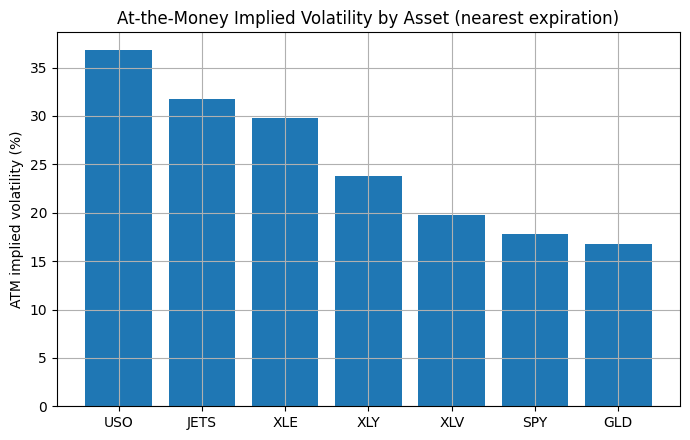

In [10]:
plt.bar(atm_summary["ticker"], atm_summary["atm_implied_vol_pct"], color="C0")
plt.ylabel("ATM implied volatility (%)")
plt.title("At-the-Money Implied Volatility by Asset (nearest expiration)")
plt.tight_layout()
plt.savefig("atm_iv_by_asset.png", dpi=130)
plt.show()


## 10. Summary

- Built a `brentq`-based implied-volatility solver with explicit no-arbitrage bounds checking
  and graceful failure handling (no crashes on bad quotes).
- Solved implied volatility for every cleaned contract across all seven assets, and recorded
  *why* any contract failed to solve.
- Fed solved implied volatilities back into the Phase 1 Greeks formulas to get market-implied
  Delta, Gamma, Vega, Theta, and Rho.
- Plotted volatility smiles per asset and compared at-the-money implied volatility across the
  full asset set.
- Saved one enriched CSV per underlying to `data/iv/`.

**Next step (Phase 4):** turn these smiles into full term structures and volatility surfaces
(moneyness x time-to-expiration x IV) -- `04_volatility_surfaces.ipynb`. Phase 5 then uses this
same implied-vol machinery around specific geopolitical event dates.
